In [11]:
#Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [12]:
df_DA_Belgium = df[ (df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Belgium') ].copy()

In [13]:
df_DA_Belgium = df_DA_Belgium.dropna(subset=['salary_year_avg'])

df_DA_Belgium_exploded = df_DA_Belgium.explode('job_skills')

df_DA_Belgium_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
26818,54988.0,express
26818,54988.0,power bi
26818,54988.0,excel
26818,54988.0,sheets
26818,54988.0,sap


In [14]:
df_DA_skills = df_DA_Belgium_exploded.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(
    'count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
df_DA_skills

,median_salary,skill_count
job_skills,,
azure,164391.00,8
go,56700.00,7
sql,111175.00,7
excel,77958.75,6
aws,165000.00,5
flow,164391.00,4
nosql,165000.00,4
power bi,84337.50,4
powerpoint,80850.00,3


In [15]:
DA_job_counts = len(df_DA_Belgium)
DA_job_counts

20

In [16]:
df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_counts * 100

df_DA_skills

,median_salary,skill_count,skill_percent
job_skills,,,
azure,164391.00,8,40.0
go,56700.00,7,35.0
sql,111175.00,7,35.0
excel,77958.75,6,30.0
aws,165000.00,5,25.0
flow,164391.00,4,20.0
nosql,165000.00,4,20.0
power bi,84337.50,4,20.0
powerpoint,80850.00,3,15.0


In [17]:
len(df_DA_skills)

28

In [18]:
df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_counts * 100
skill_percent = 20

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] >= skill_percent]
df_DA_skills_high_demand

,median_salary,skill_count,skill_percent
job_skills,,,
azure,164391.00,8,40.0
go,56700.00,7,35.0
sql,111175.00,7,35.0
excel,77958.75,6,30.0
aws,165000.00,5,25.0
flow,164391.00,4,20.0
nosql,165000.00,4,20.0
power bi,84337.50,4,20.0


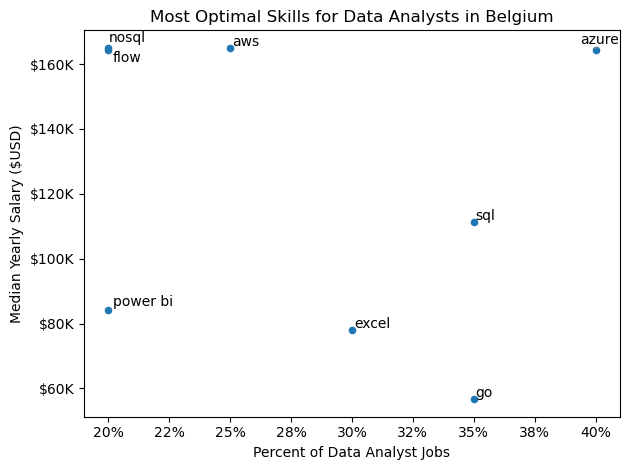

In [19]:
from adjustText import adjust_text

# 1. Create the base scatter plot
ax = df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# 2. Populate the texts list
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    # Capture the text object and append it to the list
    t = plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], 
                 df_DA_skills_high_demand['median_salary'].iloc[i], 
                 txt)
    texts.append(t)

# 3. Now adjust_text has the labels to work with!
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Belgium')

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

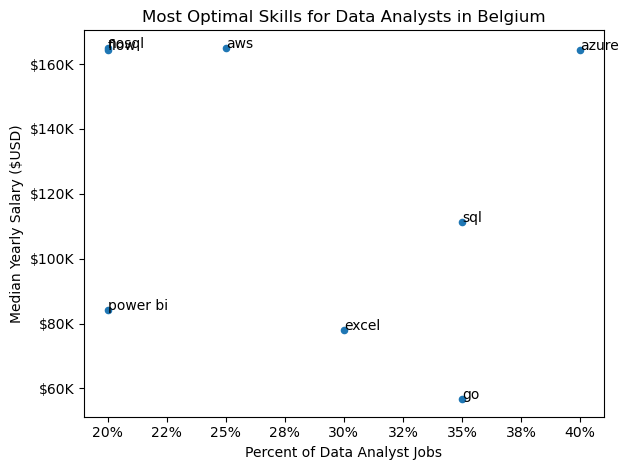

In [20]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index): 
    plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt)
    
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Belgium')

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [21]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [22]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

In [23]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)   # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:    # if key already exists in technology_dict, add value to existing key
            technology_dict[key] += value     # new and ancient values must be compatible (like both lists or strings, ...)
        else:                         # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))   #converting to set() in the process removes duplicates

technology_dict

{'analyst_tools': ['power bi',
  'cognos',
  'microstrategy',
  'sap',
  'dax',
  'looker',
  'sharepoint',
  'msaccess',
  'ms access',
  'spss',
  'qlik',
  'outlook',
  'powerbi',
  'datarobot',
  'tableau',
  'sas',
  'alteryx',
  'ssis',
  'nuix',
  'excel',
  'sheets',
  'visio',
  'esquisse',
  'word',
  'splunk',
  'ssrs',
  'spreadsheet',
  'powerpoint'],
 'programming': ['c#',
  'shell',
  'c',
  'assembly',
  'visual basic',
  'nosql',
  'vb.net',
  'sql',
  'objective-c',
  'css',
  'apl',
  'clojure',
  'go',
  'ocaml',
  'groovy',
  'php',
  'html',
  'matlab',
  'lua',
  'erlang',
  'java',
  'r',
  'kotlin',
  'visualbasic',
  'bash',
  'rust',
  'cobol',
  'haskell',
  'sass',
  'julia',
  'javascript',
  'perl',
  'sas',
  'f#',
  'dart',
  'powershell',
  'pascal',
  'typescript',
  'elixir',
  'crystal',
  'swift',
  'vba',
  'fortran',
  'lisp',
  'scala',
  'ruby',
  'python',
  'no-sql',
  'delphi',
  'golang',
  't-sql',
  'mongodb',
  'c++',
  'mongo',
  'solid

In [24]:
pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

,technology,skills
0,analyst_tools,"[power bi, cognos, microstrategy, sap, dax, lo..."
1,programming,"[c#, shell, c, assembly, visual basic, nosql, ..."
2,cloud,"[gcp, snowflake, ibm cloud, oracle, redshift, ..."
3,libraries,"[nltk, graphql, flutter, scikit-learn, rshiny,..."
4,other,"[unreal, unity, chef, terminal, atlassian, jen..."
5,databases,"[sqlserver, couchdb, elasticsearch, sql server..."
6,os,"[unix, suse, windows, kali, macos, fedora, cen..."
7,async,"[trello, airtable, monday.com, microsoft lists..."
8,webframeworks,"[ruby on rails, drupal, deno, next.js, svelte,..."
9,sync,"[zoom, ringcentral, wire, unify, twilio, googl..."


In [25]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,power bi
0,analyst_tools,cognos
0,analyst_tools,microstrategy
0,analyst_tools,sap
0,analyst_tools,dax
...,...,...
9,sync,mattermost
9,sync,rocketchat
9,sync,microsoft teams
9,sync,slack


In [26]:
df_DA_skills_high_demand

,median_salary,skill_count,skill_percent
job_skills,,,
azure,164391.00,8,40.0
go,56700.00,7,35.0
sql,111175.00,7,35.0
excel,77958.75,6,30.0
aws,165000.00,5,25.0
flow,164391.00,4,20.0
nosql,165000.00,4,20.0
power bi,84337.50,4,20.0


In [28]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,median_salary,skill_count,skill_percent,technology,skills
0,164391.00,8,40.0,cloud,azure
1,56700.00,7,35.0,programming,go
2,111175.00,7,35.0,programming,sql
3,77958.75,6,30.0,analyst_tools,excel
4,165000.00,5,25.0,cloud,aws
5,164391.00,4,20.0,other,flow
6,165000.00,4,20.0,programming,nosql
7,84337.50,4,20.0,analyst_tools,power bi


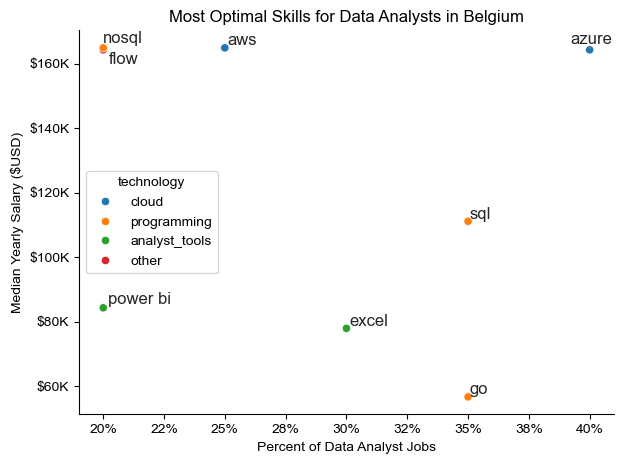

In [30]:
from adjustText import adjust_text

# 1. Create the base scatter plot
#ax = df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)
sns.despine()
sns.set_theme(style='ticks')

# 2. Populate the texts list
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    # Capture the text object and append it to the list
    t = plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], 
                 df_DA_skills_high_demand['median_salary'].iloc[i], 
                 txt)
    texts.append(t)

# 3. Now adjust_text has the labels to work with!
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Belgium')

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [32]:
print(df_DA_skills_high_demand.index.name)

job_skills
